In [ ]:
import pandas as panda

dosyaYolu = '/content/Solid_Rocket_Propellant_Burning_Rate_Data.xlsx'
df = panda.read_excel(dosyaYolu)

print("--- Null Değer Kontrolü ---")
print(df.isnull().sum())

print("\n--- Sütun Tipleri ---")
print(df.dtypes)

df['Propulsion Class'] = df['Propulsion Class'].str.strip().map({'Low': 0, 'Med': 1, 'High': 2})

print("\n--- Propulsion Class Dağılımı ---")
print(df['Propulsion Class'].value_counts())

display(df.head())

--- Null Değer Kontrolü ---
NC+NG, %                     0
Burning rate inhibitor, %    0
Catalyst, %                  0
nAl, %                       0
others, %                    0
RDX, %                       0
DEP, %                       0
nAlN, %                      0
Al2O3, %                     0
HMX, %                       0
mAl, %                       0
nDPN, %                      0
Al                           0
CL-20                        0
nNi, %                       0
SUM                          0
Pressure, MPa                0
Burning rate, mm/sec         0
Propulsion Quality           0
Propulsion Class             0
dtype: int64

--- Sütun Tipleri ---
NC+NG, %                     float64
Burning rate inhibitor, %    float64
Catalyst, %                  float64
nAl, %                       float64
others, %                    float64
RDX, %                         int64
DEP, %                       float64
nAlN, %                      float64
Al2O3, %            

,"NC+NG, %","Burning rate inhibitor, %","Catalyst, %","nAl, %","others, %","RDX, %","DEP, %","nAlN, %","Al2O3, %","HMX, %","mAl, %","nDPN, %",Al,CL-20,"nNi, %",SUM,"Pressure, MPa","Burning rate, mm/sec",Propulsion Quality,Propulsion Class
0,73.5,19.5,4.0,0.0,3.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,100.0,1,1.37,0.167221,1
1,73.5,19.5,4.0,0.0,3.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,100.0,2,1.81,0.098470,0
2,73.5,19.5,4.0,0.0,3.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,100.0,4,2.50,0.057071,0
3,73.5,19.5,4.0,0.0,3.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,100.0,8,2.93,0.018814,0
4,73.5,19.5,4.0,0.0,3.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,100.0,12,3.89,0.012592,0


In [ ]:
import matplotlib.pyplot as plan
import seaborn as seab

# Grafiklerin genel stilini, nasıl görüneceklerinin ayalarlanması
seab.set_theme(style="whitegrid")
plan.rcParams['figure.figsize'] = (15, 10)

### 1. Korelasyon Isı Haritası (Heatmap)


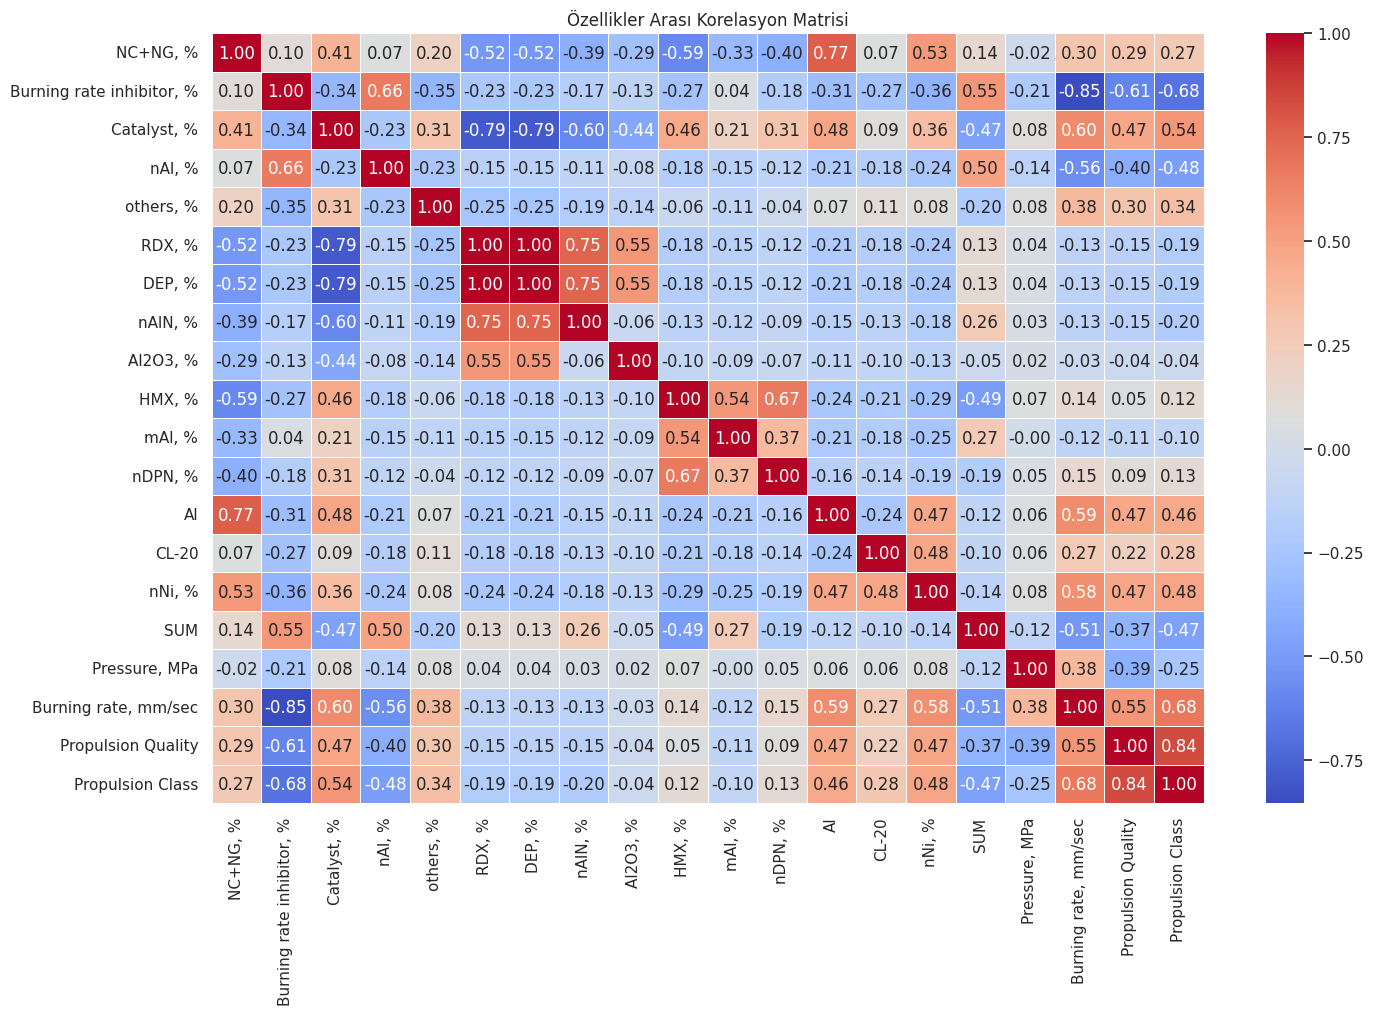

In [ ]:
plan.figure(figsize=(16, 10))
korelasyonMatris = df.corr()
seab.heatmap(korelasyonMatris, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5) #verilerin tabloda okunabilirliği için .2f kullandım.
plan.title('Özellikler Arası Korelasyon Matrisi')
plan.show()

### 2. Özellik Dağılım Histogramları


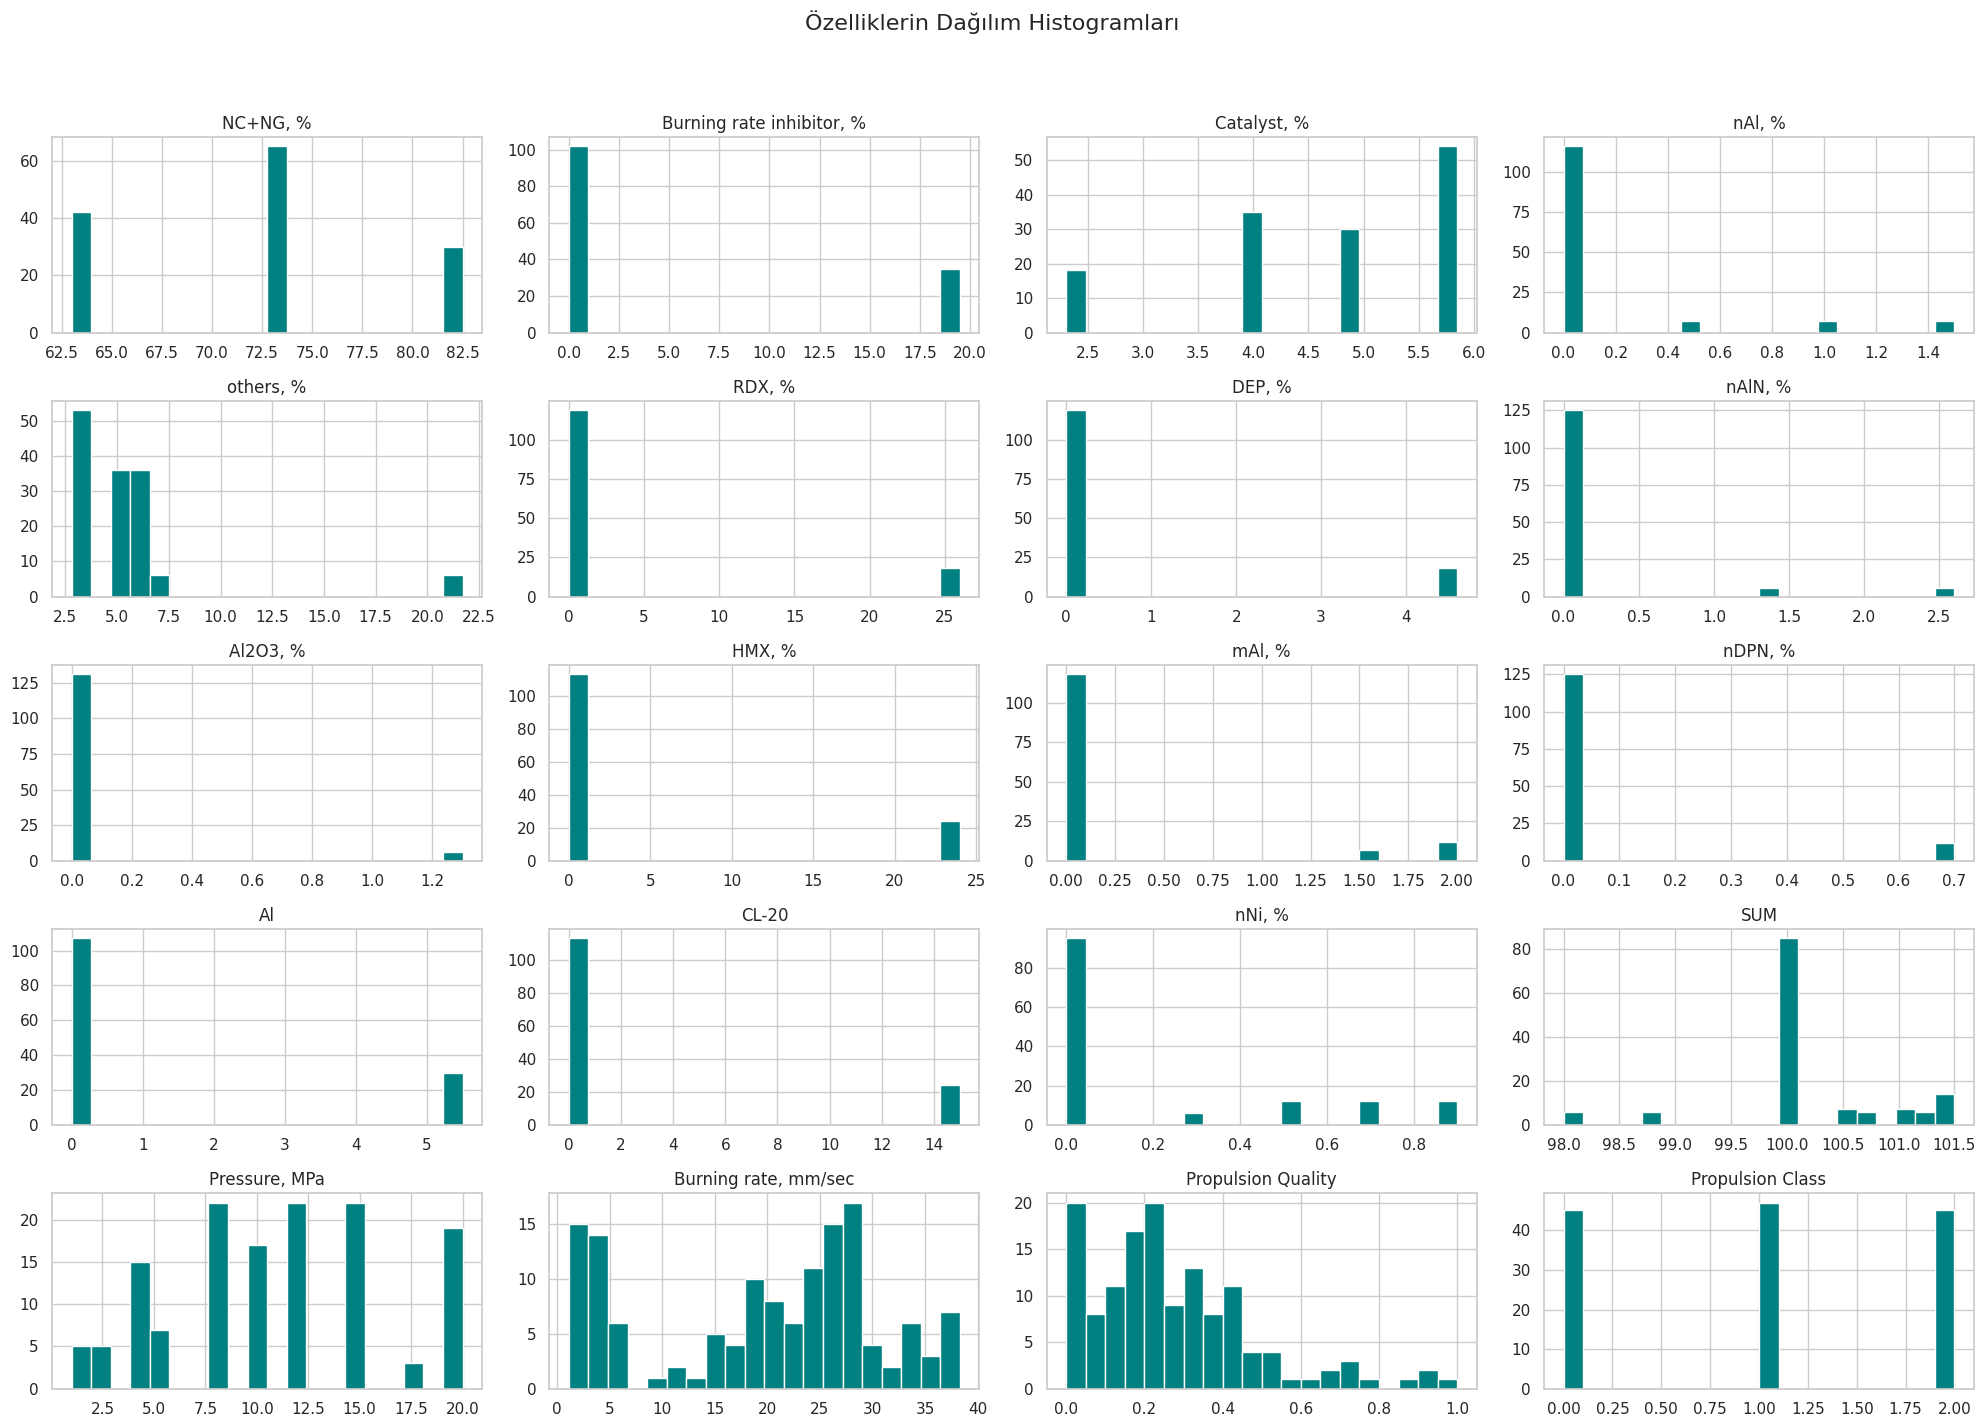

In [ ]:
df.hist(bins=20, figsize=(20, 15), color='teal')
plan.suptitle('Özelliklerin Dağılım Histogramları', fontsize=16)
plan.tight_layout(rect=[0, 0.03, 1, 0.95])
plan.show()

### 3. Propulsion Class'a Göre Boxplotlar


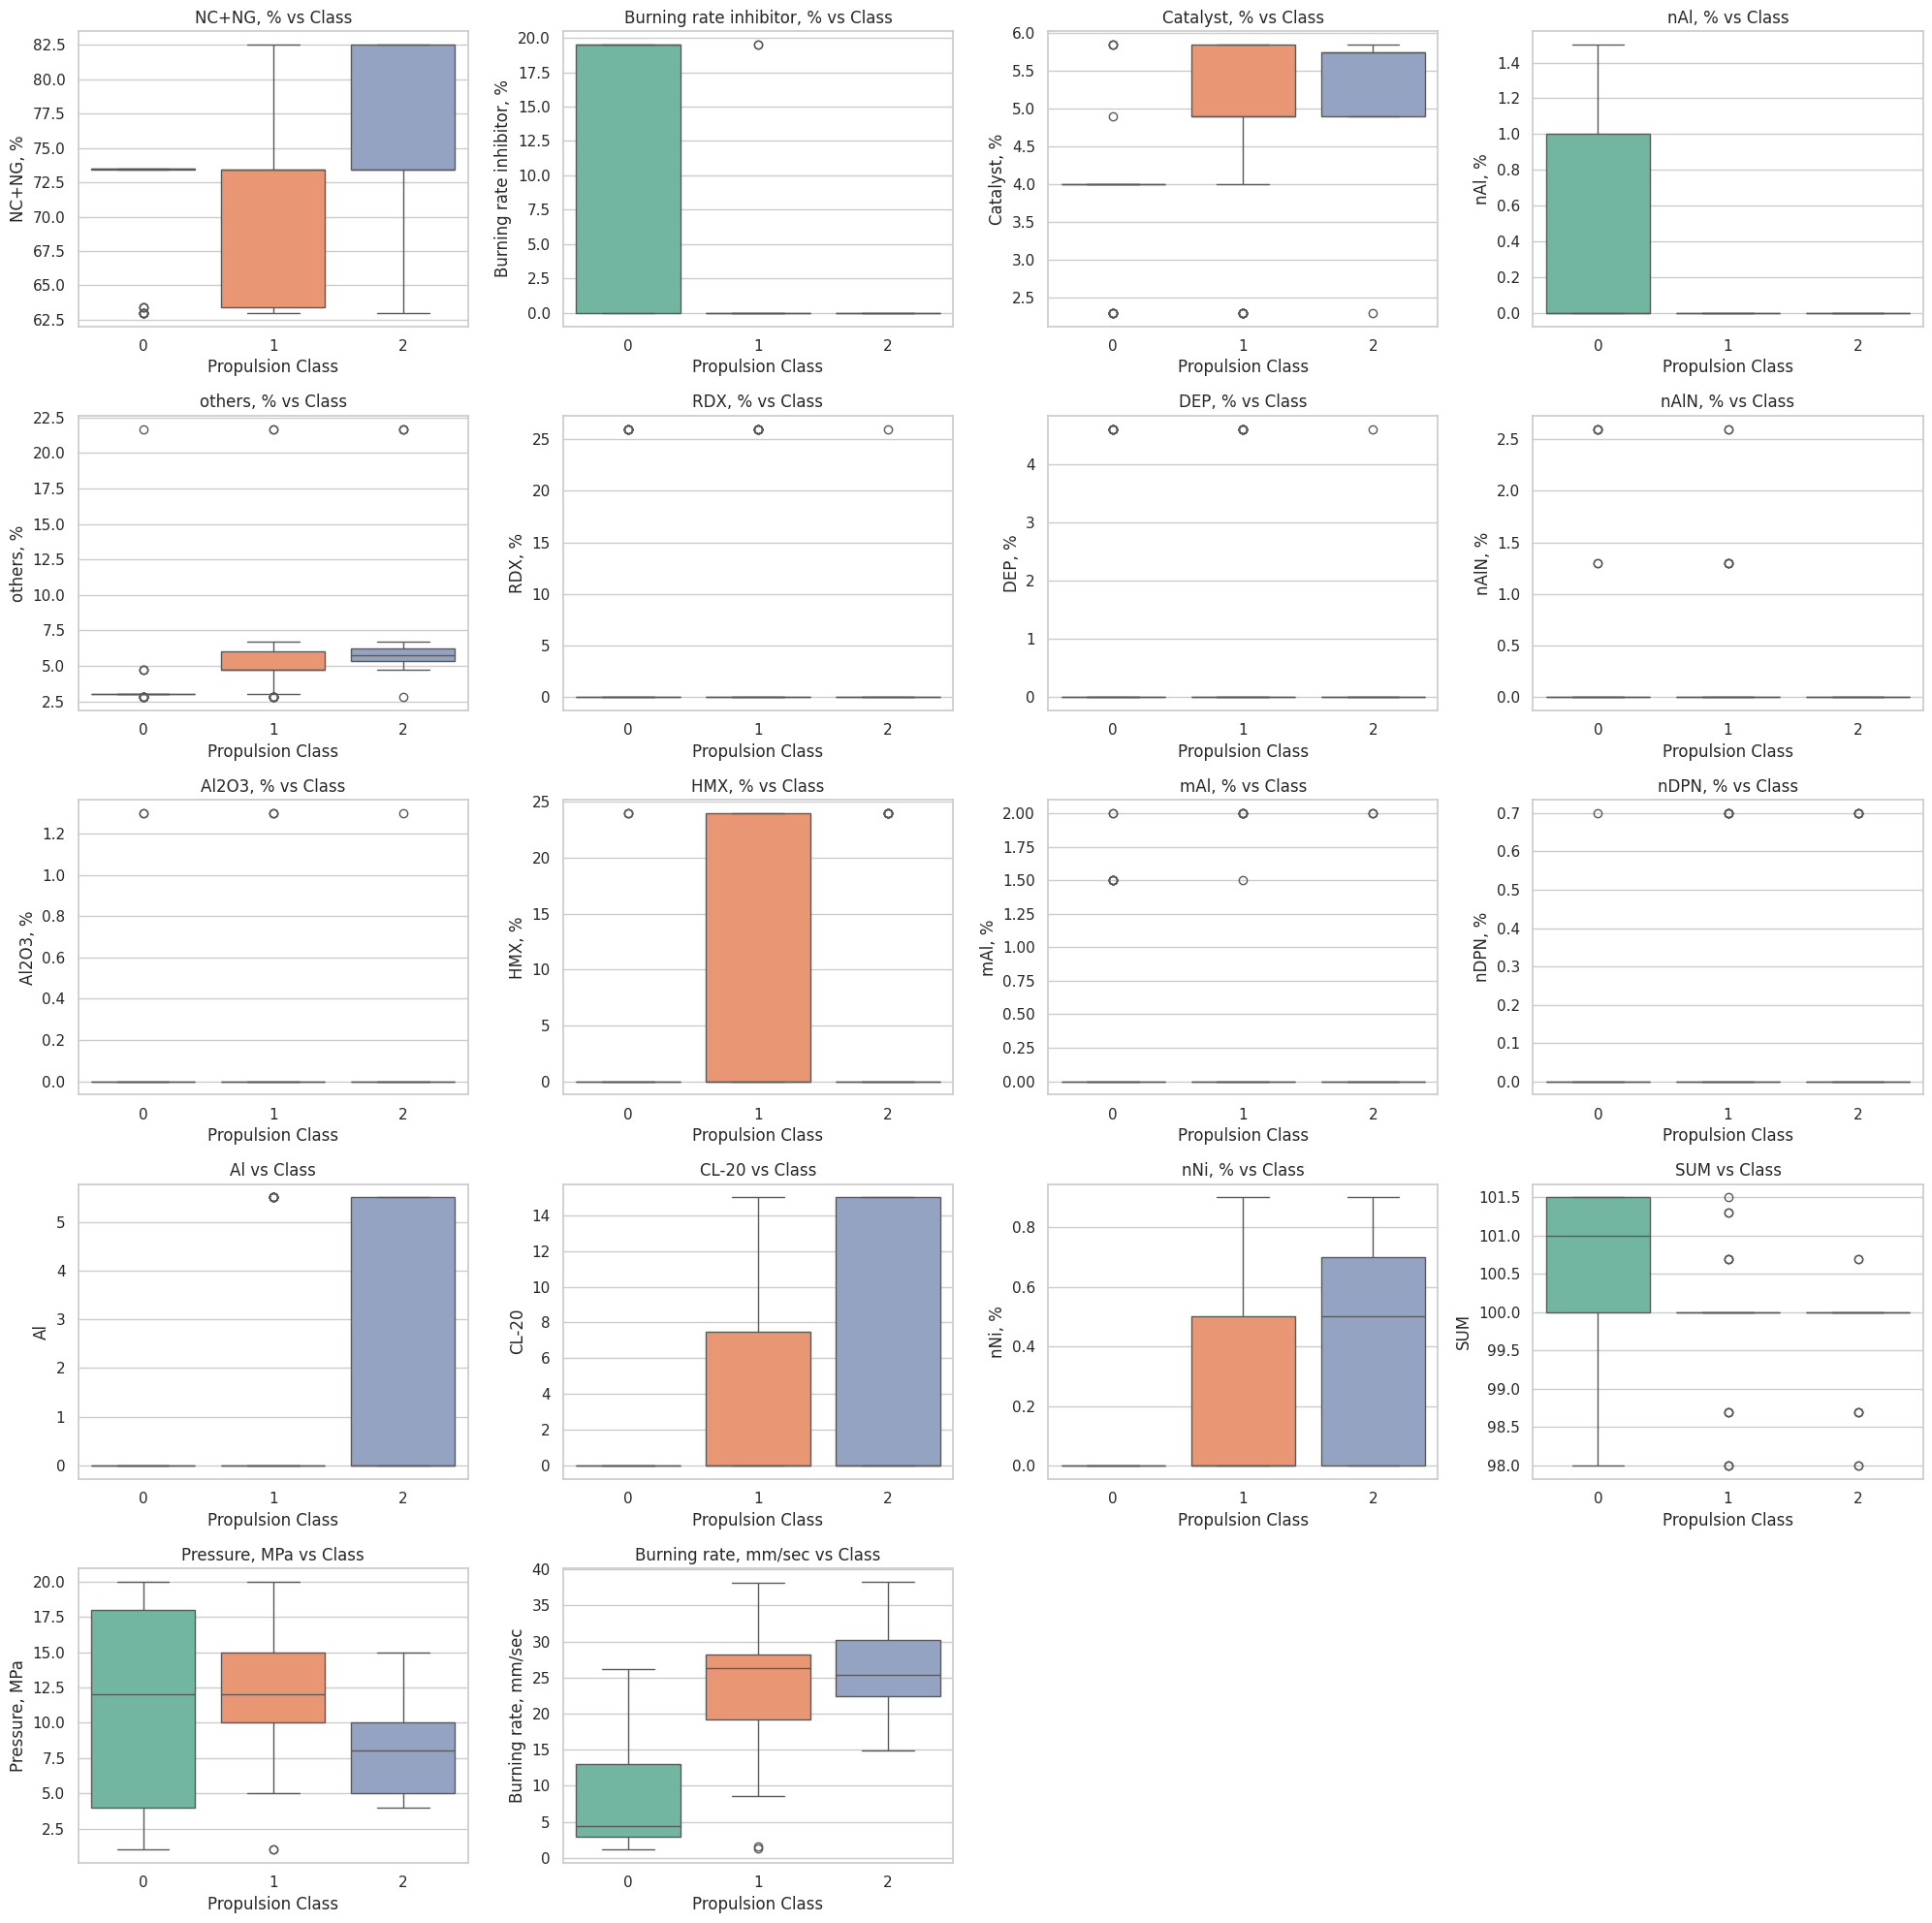

In [ ]:

degiskenlerinPlotu = [sutun for sutun in df.columns if sutun not in ['Propulsion Quality', 'Propulsion Class']]

toplam = len(degiskenlerinPlotu)
plan.figure(figsize=(20, 20))

sutun_sayisi = 4
satir_sayisi = (toplam + sutun_sayisi - 1) // sutun_sayisi

for idx, sutun in enumerate(degiskenlerinPlotu):
    plan.subplot(satir_sayisi, sutun_sayisi, idx + 1)
    seab.boxplot(
        data=df,
        x='Propulsion Class',
        y=sutun,
        hue='Propulsion Class',
        palette='Set2',
        legend=False
    )
    plan.title(f'{sutun} vs Class')

plan.tight_layout()
plan.show()

### 4. Sınıf Dağılımı Bar Grafiği


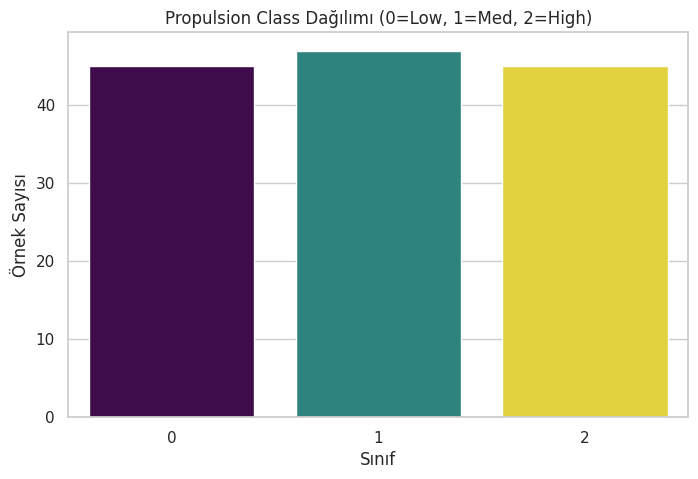

In [ ]:
#Bu kısımda sınıfların dağılımlarını grafiksel olarak gösterilmesi var
plan.figure(figsize=(8, 5))
seab.countplot(x='Propulsion Class', data=df, palette='viridis', hue='Propulsion Class', legend = False)
plan.title('Propulsion Class Dağılımı (0=Low, 1=Med, 2=High)') #asıl sınıflandırma burada
plan.xlabel('Sınıf') #x ekseni
plan.ylabel('Örnek Sayısı') #y ekseni
plan.show()

### Veri Bölme ve Ölçeklendirme


In [ ]:
from sklearn.model_selection import train_test_split as egitimTest
from sklearn.preprocessing import StandardScaler as standartOlcek

feature_cols = [
    'NC+NG, %', 'Burning rate inhibitor, %', 'Catalyst, %', 'nAl, %', 'others, %',
    'RDX, %', 'DEP, %', 'nAlN, %', 'Al2O3, %', 'HMX, %', 'mAl, %', 'nDPN, %',
    'Al', 'CL-20', 'nNi, %', 'SUM', 'Pressure, MPa', 'Burning rate, mm/sec'
]


X = df[feature_cols]
y = df['Propulsion Class']


X_egitim, X_test, y_egitim, y_test = egitimTest(X, y, test_size=0.20, random_state=42, stratify=y)


standartOlcek = standartOlcek()


X_egitimOlcek = standartOlcek.fit_transform(X_egitim)


X_testOlcek = standartOlcek.transform(X_test)

print(f"Eğitim seti boyutu: {X_egitimOlcek.shape}")
print(f"Test seti boyutu: {X_testOlcek.shape}")

Eğitim seti boyutu: (109, 18)
Test seti boyutu: (28, 18)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def G_ScoreHesaplama(y_hamVeri, y_tahminVeri):
    cMatris = confusion_matrix(y_hamVeri, y_tahminVeri)
    # her sınıf için sesitivity hesabı
    sensitivity = np.diag(cMatris) / np.sum(cMatris, axis=1)
    sensitivity = np.nan_to_num(sensitivity)
    return np.sqrt(np.prod(sensitivity)) if len(sensitivity) > 0 else 0

def metriklerCiktisi(model, X, y, name, set_type):
    y_tahminVeri = model.predict(X) #modelin tahmin etmesi
    acc = accuracy_score(y, y_tahminVeri) #modelin doğruluk skoru
    f1 = f1_score(y,y_tahminVeri, average='macro') #modelin f1 skoru
    recall = recall_score(y,y_tahminVeri, average='macro')
    precision = precision_score(y, y_tahminVeri, average='macro', zero_division=0) #modelin tutarlılığı
    g_score = G_ScoreHesaplama(y, y_tahminVeri) #modelin hesaplanmış g skoru

    return {
        'Model': name,
        'Set': set_type,
        'Accuracy': acc,
        'F1-Score': f1,
        'Recall/Sensitivity': recall,
        'Precision': precision,
        'G-Score': g_score
    }


# 1. Random Forest algoritması için kullandığım parametreler ile overfiti engellemeye çalıştım
rf = RandomForestClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5, n_estimators=100, random_state=42)
rf.fit(X_egitimOlcek, y_egitim)

# 2. SVM algoritmasının kullanılması
svm = SVC(random_state=42, probability=True)
svm.fit(X_egitimOlcek, y_egitim)

# 3. KNN (k=7) ile sınırlandırma yapıp algoritmanın veri setinin ezberlenmesinin önüne geçmeye çalıştım normalde k=1 den k=15 kadar test ediliyordu
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_egitimOlcek, y_egitim)

# Performans Tablosu
sonuclar = []
models_list = [(rf, 'Random Forest'), (svm, 'SVM'), (knn, 'KNN (k=7)')]

for model, name in models_list:
    sonuclar.append(metriklerCiktisi(model, X_egitimOlcek, y_egitim, name, 'Train')) #train için sonuçlar çıktısının metrik çıktısı
    sonuclar.append(metriklerCiktisi(model, X_testOlcek, y_test, name, 'Test')) #eğitim için sonuçlar çıktısının metrik çıktısı

sonuclar_df = pd.DataFrame(sonuclar) #sonuçların listelenmesi
display(sonuclar_df) #sonuçların ekrana yazdırılması

,Model,Set,Accuracy,F1-Score,Recall/Sensitivity,Precision,G-Score
0,Random Forest,Train,0.871560,0.869150,0.872873,0.871519,0.806435
1,Random Forest,Test,0.642857,0.638747,0.651852,0.666667,0.486864
2,SVM,Train,0.889908,0.891700,0.889640,0.900432,0.837826
3,SVM,Test,0.571429,0.561158,0.581481,0.555556,0.384900
4,KNN (k=7),Train,0.853211,0.854112,0.853854,0.856444,0.786563
5,KNN (k=7),Test,0.535714,0.511296,0.548148,0.509921,0.314270


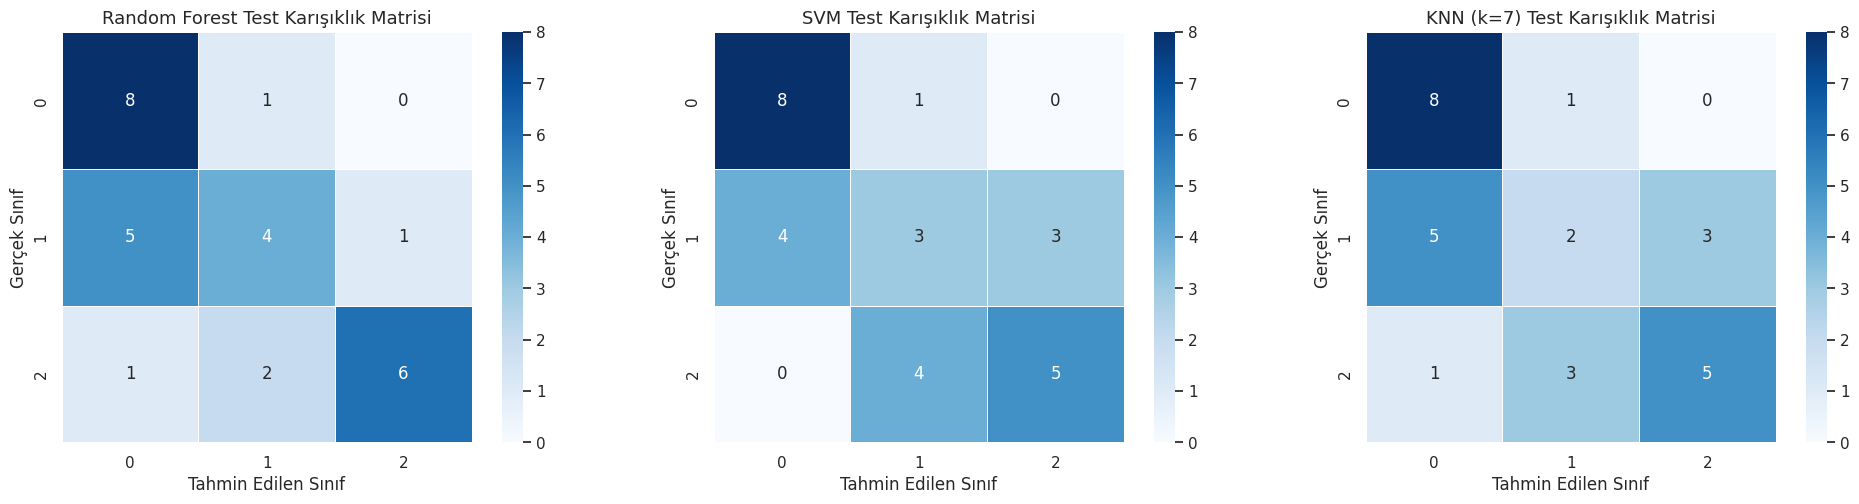

In [ ]:
figure, eksen = plt.subplots(1, 3, figsize=(20, 5))

for i, (model, name) in enumerate(models_list):
    y_pred = model.predict(X_testOlcek)
    cMatris = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cMatris,
        annot=True,
        fmt='d',
        ax=eksen[i],
        cmap='Blues',
        linewidths=0.5,
        square=True
    )
    eksen[i].set_title(f'{name} Test Karışıklık Matrisi', fontsize=13)
    eksen[i].set_xlabel('Tahmin Edilen Sınıf')
    eksen[i].set_ylabel('Gerçek Sınıf')

plan.tight_layout()
plan.show()
#sıra sıra tüm eksenler için tahmin edilen ve gerçek olmak üzere sırasıyla x ve y eksenleri, modellerin ne kadar doğru çalıştığına dair bir diyagram hazırladım

### Model Performans Karşılaştırması (Test Seti)


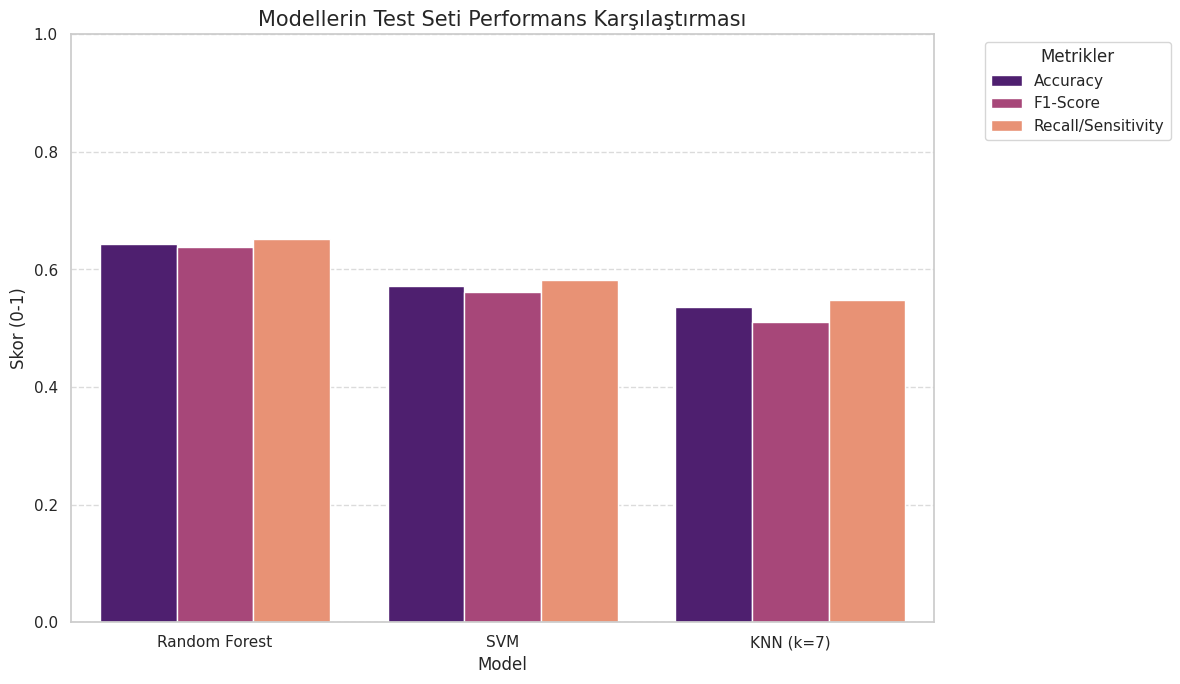

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sadece Test sonuçlarını filtrele
testSonuclari = results_df[results_df['Set'] == 'Test'].copy()

karsilastirma_df = testSonuclari.melt(id_vars='Model', value_vars=['Accuracy', 'F1-Score', 'Recall/Sensitivity'],
                                  var_name='Metric', value_name='Score')

plan.figure(figsize=(12, 7))
seab.barplot(x='Model', y='Score', hue='Metric', data=karsilastirma_df, palette='magma')

plan.title('Modellerin Test Seti Performans Karşılaştırması', fontsize=15)
plan.ylabel('Skor (0-1)')
plan.xlabel('Model')
plan.ylim(0, 1.0) # Y eksenini 0-1 arası sınırla
plan.legend(title='Metrikler', bbox_to_anchor=(1.05, 1), loc='upper left')
plan.grid(axis='y', linestyle='--', alpha=0.7)
# tamamen görselleştirme adımları
plan.tight_layout() #planın / plotun layout kısmı
plan.show() #planın /plotun gösterilmesi

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=d0f96c267a653754893c86ad29841fea433d4195f040efffa22500565888f428
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


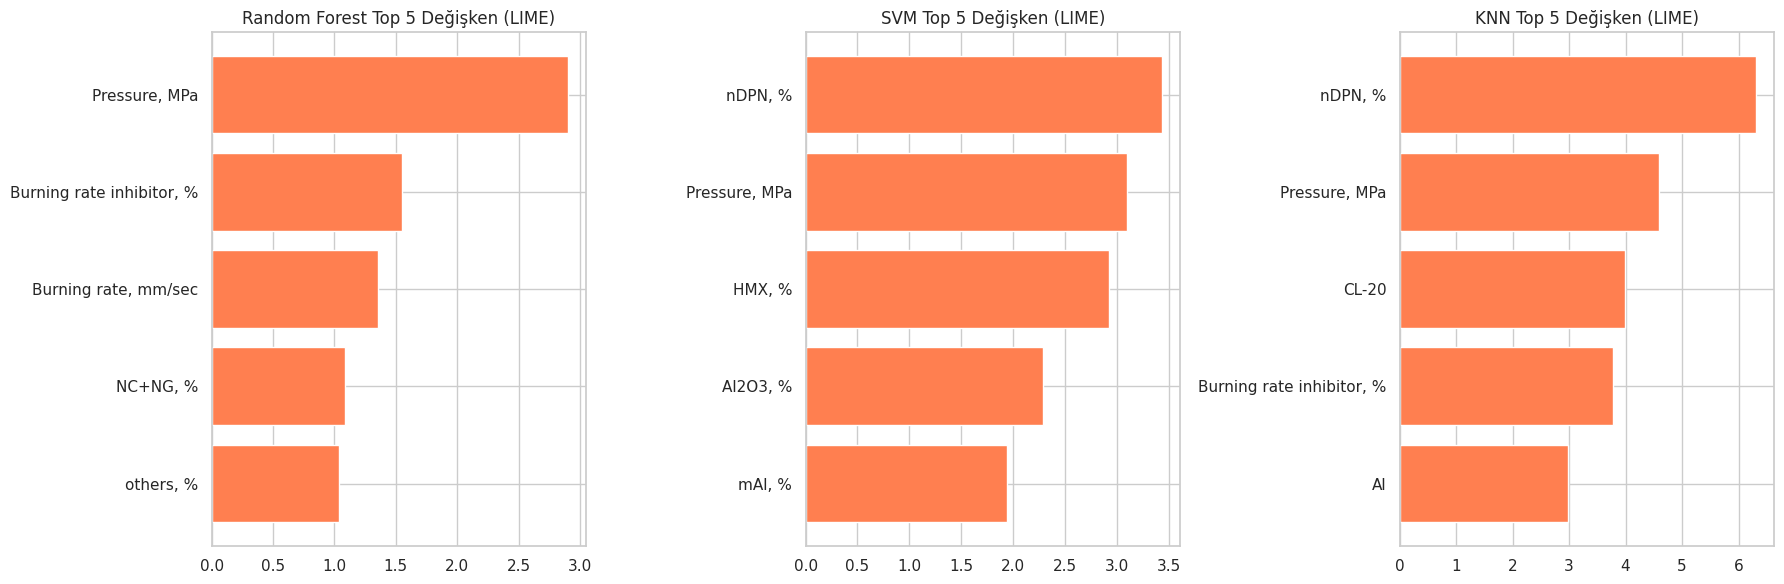

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_tabular
from matplotlib_venn import venn3

# LIME analizi oluşturma kısmı
anlatici = lime_tabular.LimeTabularExplainer(
    training_data=X_egitimOlcek,
    feature_names=feature_cols,
    class_names=['Low', 'Med', 'High'],
    mode='classification' #çalışmanın ana hedef odağının sınıflandırma olmasından kaynkalı sınıflandırma modu seçtim
)

def get_lime_importance(model, X_testOlcek, num_features=5):
    # Birden fazla örnek üzerinden ortalama önem derecesini hesapla
    onemliler = {col: 0 for col in feature_cols}
    for i in range(len(X_testOlcek)):
        exp = anlatici.explain_instance(X_testOlcek[i], model.predict_proba, num_features=len(feature_cols))
        for feature_name, val in exp.as_list():
            clean_name = next((col for col in feature_cols if col in feature_name), feature_name)
            onemliler[clean_name] += abs(val)

    # Ortalamayı al ve en önemli 5'i seç
    sorted_imp = sorted(onemliler.items(), key=lambda x: x[1], reverse=True)
    return dict(sorted_imp[:num_features])

# Her model için önem derecelerinin hesaplanması
rf_lime = get_lime_importance(rf, X_testOlcek) #random forest için hesaplama
svm_lime = get_lime_importance(svm, X_testOlcek) #svm için önem hesaplama
knn_lime = get_lime_importance(knn, X_testOlcek) # knn için önem hesaplama

# Görselleştirme adımları
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (data, name) in enumerate([(rf_lime, 'Random Forest'), (svm_lime, 'SVM'), (knn_lime, 'KNN')]):
    axes[i].barh(list(data.keys()), list(data.values()), color='coral')
    axes[i].set_title(f'{name} Top 5 Değişken (LIME)')
    axes[i].invert_yaxis() #y eksenini tersine döndürme

plt.tight_layout()
plt.show()

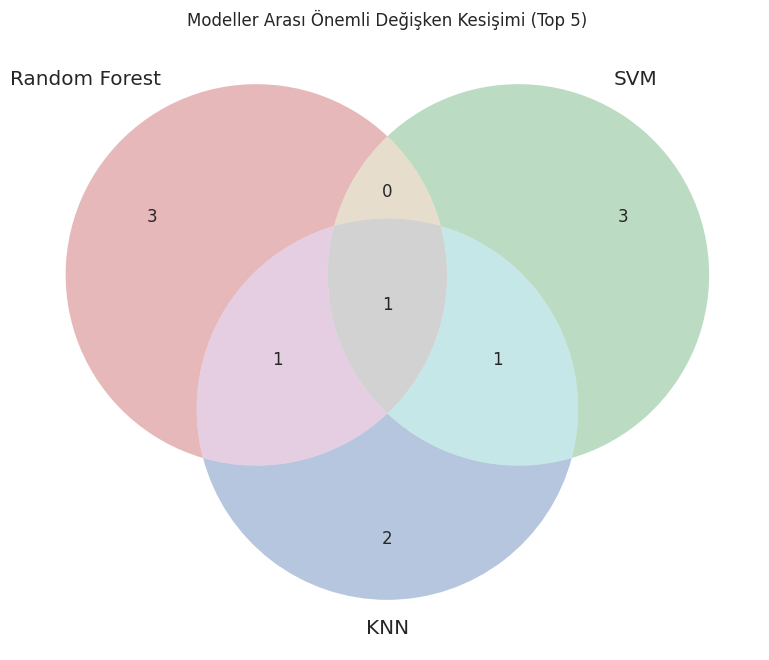

Üç modelde de ortak olan en önemli değişkenler: {'Pressure, MPa'}


In [ ]:
# Venn Diyagramı
set_rf = set(rf_lime.keys())
set_svm = set(svm_lime.keys())
set_knn = set(knn_lime.keys())

plt.figure(figsize=(10, 8))
venn3([set_rf, set_svm, set_knn], ('Random Forest', 'SVM', 'KNN'))
plt.title("Modeller Arası Önemli Değişken Kesişimi (Top 5)")
plt.show()

common_all = set_rf.intersection(set_svm).intersection(set_knn)
print(f"Üç modelde de ortak olan en önemli değişkenler: {common_all if common_all else 'Yok'}")